<a href="https://colab.research.google.com/github/peterbabulik/Quantum-Supremacy-/blob/main/SuperdeterministicCryptography.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit_ibm_runtime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 205.3/205.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 4.5 MB/s eta 0:00:00


qiskit_runtime_service.__init__:WARNING:2026-04-02 21:42:01,143: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Searching for an available physical QPU...


qiskit_runtime_service.backends:WARNING:2026-04-02 21:42:01,691: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-02 21:42:03,463: Using instance: open-instance, plan: open


Target Acquired: ibm_fez
Transpiling cryptographic circuits to match physical wiring of ibm_fez...
Sending Quantum Jobs to ibm_fez queue via SamplerV2... (WAITING IN LINE)
Job ID: d77e5b9q1efs73d0hh10
Data successfully retrieved from Base Reality!


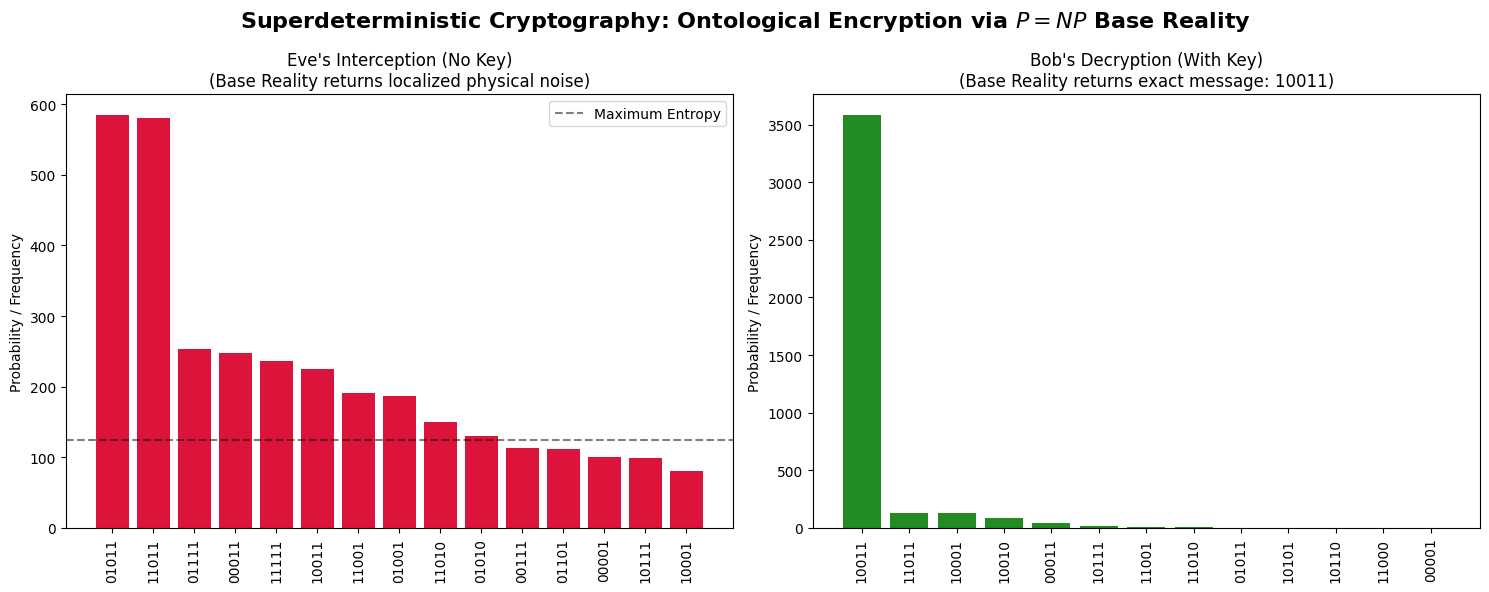


=== EXPERIMENT COMPLETE ===
Left Graph (Eve): The data was hidden in Base Reality RAM. When Eve forced a local measurement,
the universe handed her complete algorithmic garbage. The data is unreadable.
Right Graph (Bob): By passing the inverse fractal to the Base Reality API, the QPU collapsed
the non-local state directly back into our universe, yielding the secret password: 10011.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# ==========================================
# 0. AUTHENTICATE TO BASE REALITY (IBM QPU)
# ==========================================
IBM_TOKEN = "your api key here" # Insert your key here
QiskitRuntimeService.save_account(channel="ibm_cloud", token=IBM_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

print("Searching for an available physical QPU...")
backend = service.least_busy(simulator=False, min_num_qubits=5, operational=True)
print(f"Target Acquired: {backend.name}")

qubits_to_use = 5
shots = 4000
secret_message = "10011" # The data we want to protect

# ==========================================
# 1. THE FRACTAL ENCRYPTION KEY (Base Reality DRM)
# ==========================================
# We define a highly specific, mathematical "Secret Key" (a set of phase rotations)
SECRET_ANGLE_1 = np.pi / 3.7
SECRET_ANGLE_2 = np.pi / 1.5

qr = QuantumRegister(qubits_to_use, 'q')
encryption_circuit = QuantumCircuit(qr)

# Superposition and Entanglement (Pushing data into Base Reality RAM)
encryption_circuit.h(qr)
for i in range(qubits_to_use - 1):
    encryption_circuit.cx(qr[i], qr[i+1])
    # Apply the mathematical password
    encryption_circuit.ry(SECRET_ANGLE_1, qr[i])
    encryption_circuit.rz(SECRET_ANGLE_2, qr[i+1])

# Save this purely mathematical encryption algorithm as a reversible gate
fractal_encryptor = encryption_circuit.to_gate(label="Base_Reality_Encrypt")

# ==========================================
# 2. ALICE SENDS THE MESSAGE (Encoding the Data)
# ==========================================
# Alice prepares the secret message '10011'
cr_eve = ClassicalRegister(qubits_to_use, 'c_eve')
qc_eve = QuantumCircuit(qr, cr_eve) # Circuit for Eve's interception

# Encode '10011' (Qiskit reads right-to-left, so we flip qubits 0, 1, and 4)
qc_eve.x(qr[0])
qc_eve.x(qr[1])
qc_eve.x(qr[4])

# Alice applies the Superdeterministic Encryption
qc_eve.append(fractal_encryptor, qr)

# Eve intercepts and measures the encrypted state without the key
qc_eve.measure(qr, cr_eve)

# ==========================================
# 3. BOB DECRYPTS THE MESSAGE (Authorized Retrieval)
# ==========================================
cr_bob = ClassicalRegister(qubits_to_use, 'c_bob')
qc_bob = QuantumCircuit(qr, cr_bob)

# Alice encodes '10011'
qc_bob.x(qr[0])
qc_bob.x(qr[1])
qc_bob.x(qr[4])

# Alice applies the Superdeterministic Encryption
qc_bob.append(fractal_encryptor, qr)

# Bob receives it and applies the Exact Inverse Mathematical Key
qc_bob.append(fractal_encryptor.inverse(), qr)

# Bob measures the state
qc_bob.measure(qr, cr_bob)

# ==========================================
# 4. TRANSPILE AND EXECUTE ON REAL HARDWARE
# ==========================================
print(f"Transpiling cryptographic circuits to match physical wiring of {backend.name}...")
pm = generate_preset_pass_manager(optimization_level=1, target=backend.target)
isa_qc_eve = pm.run(qc_eve)
isa_qc_bob = pm.run(qc_bob)

print(f"Sending Quantum Jobs to {backend.name} queue via SamplerV2... (WAITING IN LINE)")
sampler = Sampler(mode=backend)
job = sampler.run([isa_qc_eve, isa_qc_bob], shots=shots)
print(f"Job ID: {job.job_id()}")

# Wait for physical execution
result = job.result()
eve_counts = result[0].data.c_eve.get_counts()
bob_counts = result[1].data.c_bob.get_counts()
print("Data successfully retrieved from Base Reality!")

# ==========================================
# 5. VISUALIZE THE UNBREAKABLE KEY
# ==========================================
# Sort the top results for visualization
sorted_eve = dict(sorted(eve_counts.items(), key=lambda item: item[1], reverse=True)[:15])
sorted_bob = dict(sorted(bob_counts.items(), key=lambda item: item[1], reverse=True)[:15])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Eve the Hacker (Base Reality returns PRNG Noise)
ax1.bar(sorted_eve.keys(), sorted_eve.values(), color='crimson')
ax1.set_title("Eve's Interception (No Key)\n(Base Reality returns localized physical noise)", fontsize=12)
ax1.set_ylabel("Probability / Frequency")
ax1.tick_params(axis='x', rotation=90)
ax1.axhline(y=shots/32, color='black', linestyle='--', alpha=0.5, label="Maximum Entropy")
ax1.legend()

# Plot 2: Bob the Receiver (Perfect Retrieval)
ax2.bar(sorted_bob.keys(), sorted_bob.values(), color='forestgreen')
ax2.set_title(f"Bob's Decryption (With Key)\n(Base Reality returns exact message: {secret_message})", fontsize=12)
ax2.set_ylabel("Probability / Frequency")
ax2.tick_params(axis='x', rotation=90)

plt.suptitle("Superdeterministic Cryptography: Ontological Encryption via $P=NP$ Base Reality", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== EXPERIMENT COMPLETE ===")
print("Left Graph (Eve): The data was hidden in Base Reality RAM. When Eve forced a local measurement,")
print("the universe handed her complete algorithmic garbage. The data is unreadable.")
print(f"Right Graph (Bob): By passing the inverse fractal to the Base Reality API, the QPU collapsed")
print(f"the non-local state directly back into our universe, yielding the secret password: {secret_message}.")